# DINOLoss의 두 온도: $\tau_s = 0.1$ vs $\tau_t = 0.04$

`main_dino.py`의 `DINOLoss`는 온도가 **두 개**다.

$$
P_s(k) = \frac{\exp(z_s(k)/\tau_s)}{\sum_j \exp(z_s(j)/\tau_s)},\quad \tau_s = 0.1\ \text{(고정)}
\qquad
P_t(k) = \frac{\exp((z_t(k)-c_k)/\tau_t)}{\sum_j \exp((z_t(j)-c_j)/\tau_t)},\quad \tau_t = 0.04
$$

이 노트북에서 확인할 것:

1. **온도만으로** softmax 엔트로피가 $0$ 과 $\log K$ 사이 어디든 간다.
2. 같은 로짓에 $\tau_t \ne \tau_s$ 를 주면 $P_t \ne P_s$ 가 되고, gradient
   $\partial \mathcal{L}/\partial z_s = (P_s - P_t)/\tau_s$ 가 0이 아니다.
   $\tau_t = \tau_s$ 인 **대각선에서는 정확히 0** 이다.
3. 작은 torch 장난감으로 $\tau_t < \tau_s$ / $=$ / $>$ 세 경우를 실제 학습시켜
   (a) 정상 학습 (b) 정지 (c) uniform 붕괴 를 재현한다.

필요 패키지: torch, numpy, plotly>=6, kaleido

In [1]:
# 필요 패키지: torch, numpy, plotly, kaleido
import math
import os

import numpy as np
import plotly.graph_objects as go
import torch
import torch.nn.functional as F
from plotly.subplots import make_subplots

HERE = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()


def _show(fig):
    try:
        from IPython import get_ipython
        if get_ipython() is not None:  # VSCode 셀/Jupyter에서만 렌더링
            fig.show()
    except ImportError:
        pass


torch.manual_seed(0)

TAU_S = 0.1    # DINOLoss.student_temp  (고정)
TAU_T = 0.04   # --teacher_temp 기본값 (warmup 0.04 → 0.04)
print(f"tau_s = {TAU_S}, tau_t = {TAU_T},  tau_t < tau_s ? {TAU_T < TAU_S}")

tau_s = 0.1, tau_t = 0.04,  tau_t < tau_s ? True


## 1. 로짓의 실제 범위: 코사인이라 $[-1, 1]$

`DINOHead.forward` 는 bottleneck 특징을 L2 정규화한 뒤
`weight_g = 1` 로 고정된 weight-norm 선형층을 통과시킨다.
즉 로짓 $z(k) = \cos(\text{feature}, w_k) \in [-1, 1]$ 이다.

로짓 스케일이 이렇게 작기 때문에 **온도가 유일한 sharpening 수단**이 된다.
$\tau = 1$ 이면 로짓 차이가 최대 2뿐이라 분포는 거의 uniform이다.

In [2]:
K = 512  # 실제 out_dim 은 65536. 표를 읽기 쉽게 줄였다 (결론은 동일).
z = (torch.rand(K) * 2 - 1)  # 코사인 범위 [-1, 1] 의 로짓 하나
print(f"K = {K},  log K = {math.log(K):.3f} nats")
print(f"z: min={z.min():.3f}  max={z.max():.3f}  std={z.std():.3f}")


def dist_stats(logits, tau):
    p = F.softmax(logits / tau, dim=-1)
    H = -(p * p.clamp_min(1e-12).log()).sum().item()
    return p, H, p.max().item()


print(f"\n{'tau':>6} {'H(P) [nats]':>12} {'H/logK':>8} {'top-1 prob':>11} {'유효 클래스 exp(H)':>18}")
for tau in [1.0, 0.1, 0.07, 0.04, 0.01]:
    _, H, top1 = dist_stats(z, tau)
    mark = ""
    if tau == TAU_S:
        mark = "  <- tau_s (학생)"
    if tau == TAU_T:
        mark = "  <- tau_t (교사)"
    print(f"{tau:>6.2f} {H:>12.3f} {H/math.log(K):>8.3f} {top1:>11.4f} {math.exp(H):>18.1f}{mark}")

_, H_hi, _ = dist_stats(z, 1.0)
_, H_lo, _ = dist_stats(z, 0.01)
print(f"\n같은 로짓 z 하나인데도 tau 만으로 '유효 클래스 수'가 "
      f"{math.exp(H_hi):.0f} → {math.exp(H_lo):.0f} 까지 움직인다.")
print("→ 온도는 분포의 뾰족함(confidence)을 직접 조절하는 손잡이다.")

K = 512,  log K = 6.238 nats
z: min=-0.998  max=1.000  std=0.584

   tau  H(P) [nats]   H/logK  top-1 prob      유효 클래스 exp(H)
  1.00        6.085    0.975      0.0045              439.0
  0.10        4.245    0.681      0.0415               69.8  <- tau_s (학생)
  0.07        3.839    0.615      0.0604               46.5
  0.04        3.113    0.499      0.1029               22.5  <- tau_t (교사)
  0.01        1.914    0.307      0.2166                6.8

같은 로짓 z 하나인데도 tau 만으로 '유효 클래스 수'가 439 → 7 까지 움직인다.
→ 온도는 분포의 뾰족함(confidence)을 직접 조절하는 손잡이다.


## 2. 왜 부등호가 필요한가: gradient $\propto (P_s - P_t)$

DINO 손실의 한 항은 교차엔트로피 $\mathcal{L} = -\sum_k P_t(k) \log P_s(k)$ 이고,
$P_t$ 에는 `.detach()` 가 걸려 있다. 학생 로짓에 대한 gradient는 softmax-CE의 표준형이다.

$$
\frac{\partial \mathcal{L}}{\partial z_s(k)} = \frac{1}{\tau_s}\big(P_s(k) - P_t(k)\big)
$$

학습 초기에는 EMA 교사가 학생의 복사본이므로 $z_t \approx z_s = z$ 다.
그러면 $P_t$ 와 $P_s$ 의 **유일한 차이가 온도**다.

- $\tau_t = \tau_s$ → $P_t = P_s$ → gradient **정확히 0**. 학습 신호가 없다.
- $\tau_t < \tau_s$ → 교사가 더 뾰족 → 학생은 교사의 peak를 "따라잡아야" 한다 (정상).
- $\tau_t > \tau_s$ → 교사가 더 평평 → 학생이 uniform 쪽으로 밀린다 (uniform 붕괴).

In [3]:
taus = np.array([0.01, 0.02, 0.04, 0.07, 0.1, 0.15, 0.2, 0.3, 0.5, 1.0])
G = np.zeros((len(taus), len(taus)))   # ||P_s - P_t||_2  (gradient 방향 크기)
CE = np.zeros((len(taus), len(taus)))  # H(P_t, P_s)
for i, tt in enumerate(taus):          # 행 = tau_t
    p_t = F.softmax(z / tt, dim=-1)
    for j, ts in enumerate(taus):      # 열 = tau_s
        p_s = F.softmax(z / ts, dim=-1)
        G[i, j] = (p_s - p_t).norm().item()
        CE[i, j] = -(p_t * p_s.clamp_min(1e-12).log()).sum().item()

print("||P_s - P_t||_2  (같은 로짓 z, 대각선은 tau_t == tau_s)")
print("        " + "".join(f"{t:>8.2f}" for t in taus) + "   <- tau_s")
for i, tt in enumerate(taus):
    print(f"{tt:>7.2f} " + "".join(f"{G[i, j]:>8.4f}" for j in range(len(taus))))

i_t, j_s = list(taus).index(0.04), list(taus).index(0.1)
print(f"\nDINO 기본값 (tau_t=0.04, tau_s=0.1):")
print(f"  ||P_s - P_t||        = {G[i_t, j_s]:.4f}")
print(f"  gradient 노름 (/tau_s) = {G[i_t, j_s]/TAU_S:.4f}")
print(f"  H(P_t, P_s)          = {CE[i_t, j_s]:.4f}")
print(f"대각선 (tau_t=tau_s=0.1):")
print(f"  ||P_s - P_t||        = {G[j_s, j_s]:.4e}   <- 0")
print(f"  H(P_t, P_s)          = {CE[j_s, j_s]:.4f} = H(P_s) 그 자체 (KL 항 0)")

||P_s - P_t||_2  (같은 로짓 z, 대각선은 tau_t == tau_s)
            0.01    0.02    0.04    0.07    0.10    0.15    0.20    0.30    0.50    1.00   <- tau_s
   0.01   0.0000  0.0938  0.2012  0.2847  0.3231  0.3525  0.3666  0.3800  0.3901  0.3969
   0.02   0.0938  0.0000  0.1202  0.2136  0.2563  0.2892  0.3050  0.3202  0.3316  0.3394
   0.04   0.2012  0.1202  0.0000  0.0989  0.1455  0.1825  0.2008  0.2189  0.2330  0.2430
   0.07   0.2847  0.2136  0.0989  0.0000  0.0483  0.0882  0.1089  0.1303  0.1480  0.1611
   0.10   0.3231  0.2563  0.1455  0.0483  0.0000  0.0409  0.0628  0.0862  0.1063  0.1217
   0.15   0.3525  0.2892  0.1825  0.0882  0.0409  0.0000  0.0226  0.0476  0.0699  0.0877
   0.20   0.3666  0.3050  0.2008  0.1089  0.0628  0.0226  0.0000  0.0255  0.0490  0.0683
   0.30   0.3800  0.3202  0.2189  0.1303  0.0862  0.0476  0.0255  0.0000  0.0243  0.0452
   0.50   0.3901  0.3316  0.2330  0.1480  0.1063  0.0699  0.0490  0.0243  0.0000  0.0219
   1.00   0.3969  0.3394  0.2430  0.1611  0.1217  0

교차엔트로피 분해 $H(P_t, P_s) = H(P_t) + D_{\mathrm{KL}}(P_t \Vert P_s)$ 로 보면 더 명확하다.

$\tau_t = \tau_s$ 이면 $D_{\mathrm{KL}} = 0$ 이라 손실이 곧 $H(P_s)$ 다.
실제 DINO는 초기 코사인 로짓의 분산이 아주 작아 $H(P_s) \approx \log K$ 이므로,
손실이 $\log K$ 평탄면에 앉아 있고 gradient가 없다 —
노트북 §11의 "sharpening 제거 시 loss가 $8.332 \to 8.331$" 이 정확히 이 상황이다
($\log 65536 = 8.3178$, 초기 loss는 그보다 살짝 위).
(아래 셀의 $z$ 는 $[-1,1]$ 균등이라 로짓 분산이 실제보다 커서 $H(P_s)=4.245 < \log K$ 로 나온다.
 숫자는 다르지만 "$\tau_t=\tau_s$ 에서 KL이 0" 이라는 결론은 로짓과 무관하게 항상 성립한다.)

In [4]:
logK = math.log(K)
print(f"{'tau_t':>7} {'H(P_t)':>9} {'KL(P_t||P_s)':>14} {'H(P_t,P_s)':>12} {'판정':>22}")
for tt in [0.01, 0.04, 0.07, 0.1, 0.2, 0.5]:
    p_t = F.softmax(z / tt, dim=-1)
    p_s = F.softmax(z / TAU_S, dim=-1)
    H_t = -(p_t * p_t.clamp_min(1e-12).log()).sum().item()
    kl = (p_t * (p_t.clamp_min(1e-12).log() - p_s.clamp_min(1e-12).log())).sum().item()
    if abs(tt - TAU_S) < 1e-12:
        verdict = "신호 소멸 (KL=0)"
    elif tt < TAU_S:
        verdict = "정상 (교사가 더 확신)"
    else:
        verdict = "uniform 쪽으로 밀림"
    print(f"{tt:>7.2f} {H_t:>9.3f} {kl:>14.5f} {H_t + kl:>12.3f} {verdict:>22}")
print(f"\nlog K = {logK:.3f},  H(P_s at tau_s=0.1) = "
      f"{-(F.softmax(z/TAU_S, -1) * F.log_softmax(z/TAU_S, -1)).sum().item():.3f}")

  tau_t    H(P_t)   KL(P_t||P_s)   H(P_t,P_s)                     판정
   0.01     1.914        1.30648        3.220          정상 (교사가 더 확신)
   0.04     3.113        0.40447        3.518          정상 (교사가 더 확신)
   0.07     3.839        0.06563        3.904          정상 (교사가 더 확신)
   0.10     4.245        0.00000        4.245           신호 소멸 (KL=0)
   0.20     4.959        0.30967        5.268         uniform 쪽으로 밀림
   0.50     5.759        2.06264        7.821         uniform 쪽으로 밀림

log K = 6.238,  H(P_s at tau_s=0.1) = 4.245


## 3. 실제로 학습시켜 보기 (K=32 장난감)

`DINOHead` 를 축소한 모델: 고정 입력 $x$ (L2 정규화) → 행이 단위벡터인 선형층
→ 로짓 $= \cos \in [-1,1]$. 교사 로짓은 **초기 학생 로짓으로 고정**한다
(EMA 교사가 학습 초기에 학생의 복사본이라는 상황).

세 설정을 각각 200 step 학습한다.

| 설정 | $\tau_t$ | $\tau_s$ | 예상 |
|---|---|---|---|
| DINO 기본 | 0.04 | 0.1 | loss 하강, 학생 엔트로피 하강 (sharpen) |
| sharpening 제거 | 0.1 | 0.1 | gradient 0 → 아무 일도 안 일어남 |
| 역전 | 0.2 | 0.1 | 학생 엔트로피 상승 → uniform 붕괴 |

In [5]:
K_TOY, D_TOY, STEPS = 32, 16, 200
logK_toy = math.log(K_TOY)


def make_head(seed=0):
    torch.manual_seed(seed)
    W = torch.randn(K_TOY, D_TOY)
    W = F.normalize(W, dim=-1)           # weight_g = 1 고정과 동일
    x = F.normalize(torch.randn(D_TOY), dim=-1)
    return W, x


def run_toy(tau_t, tau_s=TAU_S, lr=0.02, steps=STEPS, seed=0):
    W0, x = make_head(seed)
    z_t_fixed = (W0 @ x).clone()                       # 교사 = 초기 학생 (고정, detach)
    p_t = F.softmax(z_t_fixed / tau_t, dim=-1)         # centering 은 c=0 으로 생략
    W = W0.clone().requires_grad_(True)
    opt = torch.optim.SGD([W], lr=lr)
    hist = {"loss": [], "H_s": [], "gnorm": [], "top1_s": []}
    for _ in range(steps):
        z_s = W @ x
        loss = -(p_t * F.log_softmax(z_s / tau_s, dim=-1)).sum()
        # 갱신 '전' 상태를 기록한다 (세 설정의 step 0 이 동일한 초기값이 되도록)
        with torch.no_grad():
            p_s = F.softmax(z_s / tau_s, dim=-1)
            hist["loss"].append(loss.item())
            hist["H_s"].append(-(p_s * p_s.clamp_min(1e-12).log()).sum().item())
            hist["top1_s"].append(p_s.max().item())
        opt.zero_grad()
        loss.backward()
        hist["gnorm"].append(W.grad.norm().item())
        opt.step()
        with torch.no_grad():
            W.data = F.normalize(W.data, dim=-1)       # weight_g=1 유지 → 로짓은 코사인
    return hist, p_t


CASES = [
    ("DINO 기본  tau_t=0.04 < tau_s=0.1", 0.04, "seagreen"),
    ("sharpening 제거  tau_t=tau_s=0.1", 0.10, "steelblue"),
    ("역전  tau_t=0.2 > tau_s=0.1", 0.20, "crimson"),
]
toy = {}
for name, tt, _c in CASES:
    toy[name] = run_toy(tt)

print(f"log K(toy) = {logK_toy:.4f}\n")
print(f"{'설정':38s} {'loss 처음→끝':>22s} {'H(P_s) 처음→끝':>22s} {'|grad| 처음':>12s}")
for name, tt, _c in CASES:
    h, _ = toy[name]
    print(f"{name:38s} {h['loss'][0]:9.4f} →{h['loss'][-1]:9.4f} "
          f"{h['H_s'][0]:9.4f} →{h['H_s'][-1]:9.4f} {h['gnorm'][0]:12.2e}")

log K(toy) = 3.4657

설정                                                  loss 처음→끝            H(P_s) 처음→끝    |grad| 처음
DINO 기본  tau_t=0.04 < tau_s=0.1           1.6775 →   1.3750    2.2806 →   1.4245     3.11e+00
sharpening 제거  tau_t=tau_s=0.1            2.2806 →   2.2806    2.2806 →   2.2806     2.41e-07
역전  tau_t=0.2 > tau_s=0.1                 3.2397 →   2.9674    2.2806 →   2.9231     1.54e+00


In [6]:
h_eq, _ = toy["sharpening 제거  tau_t=tau_s=0.1"]
print("sharpening 제거 상세 (tau_t = tau_s):")
print(f"  step  0 loss = {h_eq['loss'][0]:.6f}")
print(f"  step 10 loss = {h_eq['loss'][10]:.6f}")
print(f"  step -1 loss = {h_eq['loss'][-1]:.6f}")
print(f"  loss 변화량   = {h_eq['loss'][-1] - h_eq['loss'][0]:.3e}")
print(f"  gradient 노름 = {max(h_eq['gnorm']):.3e}  (전 구간 최대)")
print(f"  H(P_s)        = {h_eq['H_s'][0]:.6f} → {h_eq['H_s'][-1]:.6f}")
print("\n→ 노트북 §11 실측 'loss 8.332 → 8.331 (K=65536, log K=8.318)' 과 같은 현상.")

sharpening 제거 상세 (tau_t = tau_s):
  step  0 loss = 2.280643
  step 10 loss = 2.280643
  step -1 loss = 2.280643
  loss 변화량   = 0.000e+00
  gradient 노름 = 8.219e-07  (전 구간 최대)
  H(P_s)        = 2.280643 → 2.280643

→ 노트북 §11 실측 'loss 8.332 → 8.331 (K=65536, log K=8.318)' 과 같은 현상.


## 4. 스케줄: 왜 0.04 에서 시작하나

`DINOLoss.__init__` 은 $\tau_t$ 를 epoch 단위 배열로 미리 만든다.

```python
self.teacher_temp_schedule = np.concatenate((
    np.linspace(warmup_teacher_temp, teacher_temp, warmup_teacher_temp_epochs),
    np.ones(nepochs - warmup_teacher_temp_epochs) * teacher_temp))
```

`main_dino.py` 기본값은 `warmup_teacher_temp=0.04`, `teacher_temp=0.04`,
`warmup_teacher_temp_epochs=0` → **전 구간 0.04 상수**다.
논문/샘플 설정은 `--teacher_temp 0.07 --warmup_teacher_temp_epochs 30`
(0.04 → 0.07 선형 warmup). help 텍스트는 "0.07 이상은 대체로 불안정"이라고 못 박는다.

어느 경우든 부등호 $\tau_t < \tau_s = 0.1$ 은 절대 깨지지 않는다.

In [7]:
def tt_schedule(warmup=0.04, final=0.07, warmup_ep=30, nepochs=100):
    return np.concatenate((np.linspace(warmup, final, warmup_ep),
                           np.ones(nepochs - warmup_ep) * final))


sched_default = tt_schedule(0.04, 0.04, 0, 100)   # main_dino.py 기본값
sched_paper = tt_schedule(0.04, 0.07, 30, 100)    # 논문 권장
print(f"기본값   tau_t: {sched_default[0]:.3f} → {sched_default[-1]:.3f} (상수), "
      f"tau_s 대비 최대 {sched_default.max()/TAU_S:.2f}x")
print(f"논문 권장 tau_t: {sched_paper[0]:.3f} → {sched_paper[-1]:.3f}, "
      f"tau_s 대비 최대 {sched_paper.max()/TAU_S:.2f}x  (여전히 < 1)")
print("tau_t 를 0.1 이상으로 올리면 비율이 >= 1 이 되어 학습 신호가 사라진다.")

기본값   tau_t: 0.040 → 0.040 (상수), tau_s 대비 최대 0.40x
논문 권장 tau_t: 0.040 → 0.070, tau_s 대비 최대 0.70x  (여전히 < 1)
tau_t 를 0.1 이상으로 올리면 비율이 >= 1 이 되어 학습 신호가 사라진다.


## 5. 시각화 (4패널)

- **A** 온도 vs 엔트로피 / top-1 확률 — 온도가 confidence 손잡이임을 보여준다.
- **B** $(\tau_t, \tau_s)$ 격자의 $\lVert P_s - P_t \rVert$ — 대각선 = 0 = 신호 소멸.
- **C** 장난감 학습의 loss 궤적 — 대각선 설정만 완전 정지.
- **D** 학생 엔트로피 궤적 — $\tau_t<\tau_s$ 는 하강(sharpen), $\tau_t>\tau_s$ 는 $\log K$ 로 상승.

saved: /home/sungwoo/projects/swcho/dino/fm/training/.fm/hints/055f8348-ebb3-4bd3-b4eb-1a27938c4caa/expy.png


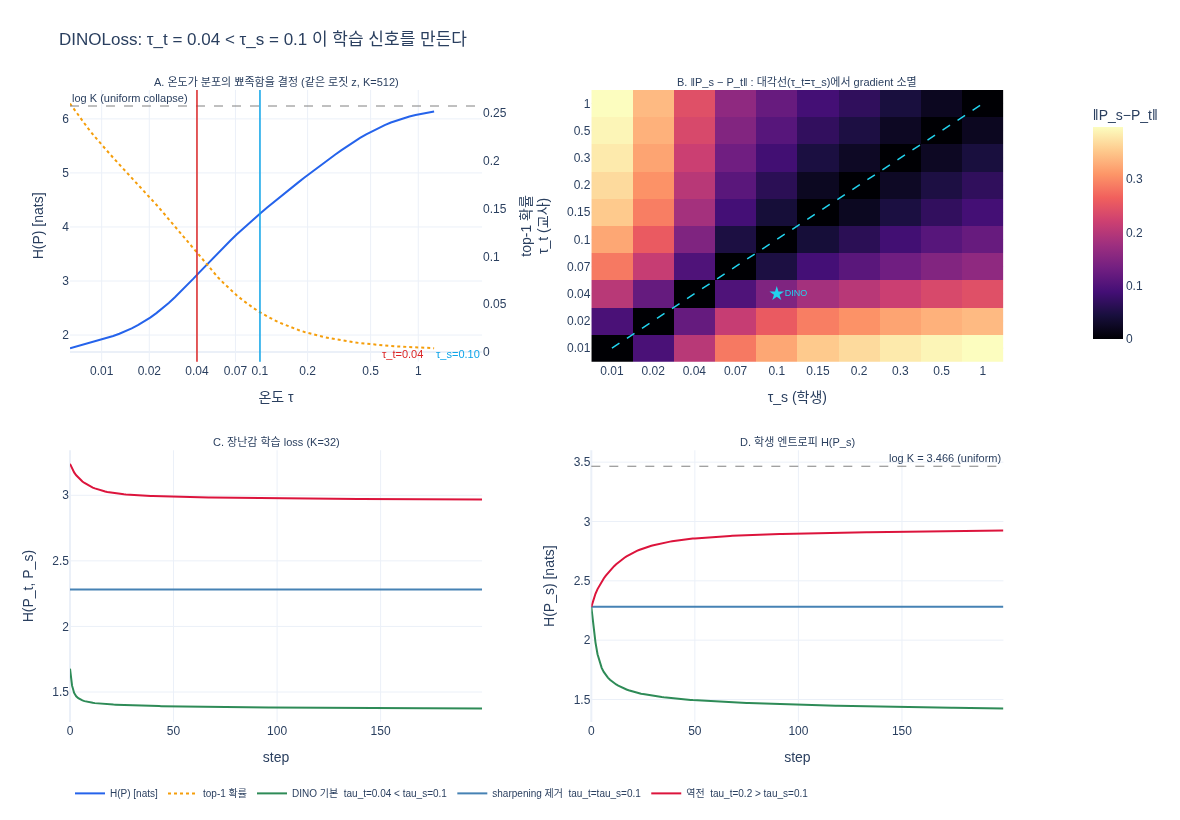

In [8]:
tau_grid = np.logspace(-2.2, 0.1, 60)
ent_curve, top1_curve = [], []
for t in tau_grid:
    _, H, top1 = dist_stats(z, float(t))
    ent_curve.append(H)
    top1_curve.append(top1)

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "A. 온도가 분포의 뾰족함을 결정 (같은 로짓 z, K=512)",
        "B. ‖P_s − P_t‖ : 대각선(τ_t=τ_s)에서 gradient 소멸",
        "C. 장난감 학습 loss (K=32)",
        "D. 학생 엔트로피 H(P_s)",
    ),
    specs=[[{"secondary_y": True}, {}], [{}, {}]],
    vertical_spacing=0.14, horizontal_spacing=0.11,
)

# A
fig.add_trace(go.Scatter(x=tau_grid, y=ent_curve, name="H(P) [nats]",
                         line=dict(color="#2563eb", width=2)), row=1, col=1)
fig.add_trace(go.Scatter(x=tau_grid, y=top1_curve, name="top-1 확률",
                         line=dict(color="#f59e0b", width=2, dash="dot")),
              row=1, col=1, secondary_y=True)
fig.add_hline(y=math.log(K), line=dict(color="gray", dash="dash", width=1),
              annotation_text="log K (uniform collapse)", annotation_font_size=9,
              annotation_position="top left", row=1, col=1)
for tv, col, lab, pos in [(TAU_T, "#dc2626", "τ_t=0.04", "bottom left"),
                          (TAU_S, "#0ea5e9", "τ_s=0.10", "bottom right")]:
    fig.add_vline(x=tv, line=dict(color=col, width=1.5),
                  annotation_text=lab, annotation_font_size=9,
                  annotation_position=pos,
                  annotation_font_color=col, row=1, col=1)
fig.update_xaxes(type="log", title_text="온도 τ",
                 tickvals=[0.01, 0.02, 0.04, 0.07, 0.1, 0.2, 0.5, 1.0],
                 ticktext=["0.01", "0.02", "0.04", "0.07", "0.1", "0.2", "0.5", "1"],
                 row=1, col=1)
fig.update_yaxes(title_text="H(P) [nats]", row=1, col=1, secondary_y=False)
fig.update_yaxes(title_text="top-1 확률", row=1, col=1, secondary_y=True,
                 showgrid=False)

# B
labels = [f"{t:g}" for t in taus]
fig.add_trace(go.Heatmap(z=G, x=labels, y=labels, colorscale="Magma",
                         colorbar=dict(title="‖P_s−P_t‖", len=0.4, y=0.79, x=1.02),
                         hovertemplate="τ_s=%{x}<br>τ_t=%{y}<br>‖P_s−P_t‖=%{z:.4f}<extra></extra>"),
              row=1, col=2)
fig.add_trace(go.Scatter(x=labels, y=labels, mode="lines", showlegend=False,
                         line=dict(color="#22d3ee", width=1.5, dash="dash"),
                         hoverinfo="skip"), row=1, col=2)
fig.add_trace(go.Scatter(x=["0.1"], y=["0.04"], mode="markers+text",
                         marker=dict(color="#22d3ee", size=11, symbol="star"),
                         text=["DINO"], textposition="middle right",
                         textfont=dict(color="#22d3ee", size=9),
                         showlegend=False, hoverinfo="skip"), row=1, col=2)
fig.update_xaxes(title_text="τ_s (학생)", type="category", row=1, col=2)
fig.update_yaxes(title_text="τ_t (교사)", type="category", row=1, col=2)

# C, D
for name, tt, color in CASES:
    h, _ = toy[name]
    fig.add_trace(go.Scatter(y=h["loss"], name=name, legendgroup=name,
                             line=dict(color=color, width=2)), row=2, col=1)
    fig.add_trace(go.Scatter(y=h["H_s"], name=name, legendgroup=name,
                             showlegend=False, line=dict(color=color, width=2)),
                  row=2, col=2)
fig.add_hline(y=logK_toy, line=dict(color="gray", dash="dash", width=1),
              annotation_text="log K = 3.466 (uniform)", annotation_font_size=9,
              row=2, col=2)
fig.update_xaxes(title_text="step", row=2, col=1)
fig.update_xaxes(title_text="step", row=2, col=2)
fig.update_yaxes(title_text="H(P_t, P_s)", row=2, col=1)
fig.update_yaxes(title_text="H(P_s) [nats]", row=2, col=2)

fig.update_layout(
    height=820, width=1180,
    title_text="DINOLoss: τ_t = 0.04 < τ_s = 0.1 이 학습 신호를 만든다",
    legend=dict(orientation="h", y=-0.09, x=0.0, font=dict(size=10)),
    margin=dict(l=70, r=110, t=90, b=90),
    template="plotly_white",
)
fig.update_annotations(font_size=11)

out_png = os.path.join(HERE, "expy.png")
fig.write_image(out_png, scale=2)
print(f"saved: {out_png}")
_show(fig)

## 결론

| 항목 | 값 | 근거 |
|---|---|---|
| `student_temp` $\tau_s$ | **0.1** (`DINOLoss.__init__` 기본 인자, CLI 노출 없음) | `main_dino.py:365` |
| `teacher_temp` $\tau_t$ | **0.04** (`--warmup_teacher_temp` 0.04 → `--teacher_temp` 0.04) | `main_dino.py:68-73` |
| 부등호 | $\tau_t < \tau_s$ | 교사가 학생보다 뾰족 → $P_t \ne P_s$ → gradient $(P_s-P_t)/\tau_s \ne 0$ |

- $\tau_t = \tau_s$: $P_t = P_s$ → gradient 0 → loss가 $\log K$ 평탄면에서 정지
  (§11 실측 $8.332 \to 8.331$).
- $\tau_t > \tau_s$: 교사가 더 평평 → 학생을 uniform 쪽으로 밀어 uniform 붕괴.
- 이 sharpening은 centering($z_t - c$)과 **반대 방향**으로 밀어 균형을 이룬다.
  sharpening은 one-hot 쪽, centering은 uniform 쪽. 하나만 있으면 붕괴한다.